In [ ]:
!pip install skl2onnx
!pip install pytorch-optimizer
!pip install onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 116.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 4.1 MB/s eta 0:00:00


In [ ]:
import os, sys
import timeit
import random
import math
from contextlib import redirect_stdout
import datetime
import csv

import numpy as np
import pandas as pd
import sklearn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score)
from pytorch_optimizer import Ranger

import skl2onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType


from google.colab import drive

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cuda


In [ ]:
def set_seed(seed=22):
  torch.manual_seed(seed)
  np.random.seed(seed)
  random.seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
set_seed(22)

In [ ]:
drive.mount('/content/drive')
DEV_PATH = ('/content/drive/MyDrive/ASV_Final_Features_dev.pkl', 'dev')
EVAL_PATH = ('/content/drive/MyDrive/ASV_Final_Features_eval.pkl', 'eval')
TRAIN_PATH = ('/content/drive/MyDrive/ASV_Final_Features_train.pkl', 'train')

def load_dataset(path):
  df = pd.read_pickle(path[0])
  print(f"DataFrame loaded for {path[1]} sample set. Total samples: {len(df)}. Dataframe shape: {df.shape}")
  return df

Mounted at /content/drive


In [ ]:
train_df = load_dataset(TRAIN_PATH)
dev_df   = load_dataset(DEV_PATH)
eval_df  = load_dataset(EVAL_PATH)

print(train_df['label'].value_counts())
print(dev_df['label'].value_counts())
print(eval_df['label'].value_counts())

DataFrame loaded for train sample set. Total samples: 25380. Dataframe shape: (25380, 5)
DataFrame loaded for dev sample set. Total samples: 24844. Dataframe shape: (24844, 5)
DataFrame loaded for eval sample set. Total samples: 71237. Dataframe shape: (71237, 5)
label
1    22800
0     2580
Name: count, dtype: int64
label
1    22296
0     2548
Name: count, dtype: int64
label
1    63882
0     7355
Name: count, dtype: int64


In [ ]:
def prepare_tensors(df, feature_col='1dcnn_features', label_col='label'):
  X = np.stack(df[feature_col].values).transpose(0, 2, 1).astype(np.float32)
  y = df[label_col].values
  return torch.from_numpy(X), torch.from_numpy(y)

In [ ]:
X_train_tr, y_train_tr = prepare_tensors(train_df)
X_dev_tr, y_dev_tr = prepare_tensors(dev_df)
X_eval_tr, y_eval_tr = prepare_tensors(eval_df)

In [ ]:
batch_size = 256
learning_rate = 0.001
epochs = 200
epsilon = 0.0001

In [ ]:
x_means = X_train_tr.mean(dim=(0,2), keepdim=True)
x_stds = X_train_tr.std(dim=(0,2), keepdim=True) + epsilon

train_ds = TensorDataset(X_train_tr, y_train_tr)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=2)

dev_ds = TensorDataset(X_dev_tr, y_dev_tr)
dev_dl = DataLoader(dev_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=0)

eval_ds = TensorDataset(X_eval_tr, y_eval_tr)
eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=0)

print(f"Train Input Tensor Shape: {X_train_tr.shape}")
print(f"Train Output Tensor Shape: {y_train_tr.shape}")

print(f"Dev Input Tensor Shape: {X_dev_tr.shape}")
print(f"Dev Output Tensor Shape: {y_dev_tr.shape}")

print(f"Eval Input Tensor Shape: {X_eval_tr.shape}")
print(f"Eval Output Tensor Shape: {y_eval_tr.shape}")


Train Input Tensor Shape: torch.Size([25380, 40, 126])
Train Output Tensor Shape: torch.Size([25380])
Dev Input Tensor Shape: torch.Size([24844, 40, 126])
Dev Output Tensor Shape: torch.Size([24844])
Eval Input Tensor Shape: torch.Size([71237, 40, 126])
Eval Output Tensor Shape: torch.Size([71237])


In [ ]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.SiLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

In [ ]:
class AttentivePooling(nn.Module):
    def __init__(self, in_channels):
        super(AttentivePooling, self).__init__()
        self.attention = nn.Linear(in_channels, 1)

    def forward(self, x):
        x_trans = x.transpose(1, 2)

        weights = self.attention(x_trans)

        weights = torch.softmax(weights, dim=1)

        pooled = torch.sum(x_trans * weights, dim=1)

        return pooled

In [ ]:
class Deepfake_1DCNN(nn.Module):
    def __init__(self, means, stds):
        super(Deepfake_1DCNN, self).__init__()

        self.register_buffer('means', means.detach().clone().view(1, 40, 1))
        self.register_buffer('stds', stds.detach().clone().view(1, 40, 1))

        self.conv1 = nn.Conv1d(in_channels=40, out_channels=32, kernel_size=5,
                               stride=1, padding=8, dilation=4)
        self.bn1 = nn.BatchNorm1d(32)
        self.silu = nn.SiLU()

        self.se = SEBlock(32)

        self.att_pool = AttentivePooling(32)

        self.fc1 = nn.Linear(128, 16)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        #Normalization
        x = (x - self.means) / (self.stds + 1e-7)

        #Feature Extraction
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.silu(x)

        #Attention
        x = self.se(x)

        #Pooling
        mean_p = torch.mean(x, dim=2)
        std_p = torch.std(x, dim=2)
        max_p, _ = torch.max(x, dim=2)
        att_p = self.att_pool(x)

        #(32 * 4 = 128)
        x = torch.cat((mean_p, std_p, max_p, att_p), dim=1)

        #Classification
        x = self.fc1(x)
        x = self.silu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
def training_loop(epochs, model, loss_fn, opt, train_dl, dev_dl, device, scheduler=None, patience=10):
    original_show = plt.show
    plt.show = lambda *args, **kwargs: None

    best_dev_eer = float('inf')
    epochs_without_improvement = 0
    best_model_state = None

    print(f"{'Epoch':<6} | {'Train Loss':<10} | {'Dev EER':<10} | {'LR':<10}")
    print("-" * 50)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)

            #Forward & Backward
            y_pred = model(xb)
            loss = loss_fn(y_pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            #Batch-level update for OneCycleLR
            if scheduler:
                scheduler.step()

            running_loss += loss.item()

        #Epoch Evaluation
        with open(os.devnull, 'w') as f, redirect_stdout(f):
            current_dev_eer, _ = eval_model(model, dev_dl, device)
        plt.close('all')

        avg_loss = running_loss / len(train_dl)
        current_lr = opt.param_groups[0]['lr']

        print(f"[{epoch:02d}]   | {avg_loss:.4f}     | {current_dev_eer:.2f}%     | {current_lr:.6f}")

        #Early Stopping check on Dev EER
        if current_dev_eer < best_dev_eer:
            best_dev_eer = current_dev_eer
            epochs_without_improvement = 0
            # Clone state to CPU to save GPU memory
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"\n[!] Early Stopping triggered after {patience} epochs of no improvement.")
            print(f"Best Dev EER achieved: {best_dev_eer:.2f}%")
            break

    #Restore environment and best model
    plt.show = original_show
    if best_model_state:
        model.load_state_dict(best_model_state)
    return best_dev_eer

In [ ]:
def eval_model(model, dl, device, dataset_name="Dataset"):
  model.eval()
  all_labels = []
  all_preds = []
  all_scores = []

  with torch.no_grad():
    for xb, yb in dl:
      xb, yb = xb.to(device), yb.to(device)

      outputs = model(xb)
      probs = torch.softmax(outputs, dim=1)
      preds = torch.argmax(probs, dim=1)

      all_labels.extend(yb.cpu().numpy())
      all_preds.extend(preds.cpu().numpy())
      all_scores.extend(probs[:, 0].cpu().numpy())

  all_labels = np.array(all_labels)
  all_preds = np.array(all_preds)
  all_scores = np.array(all_scores)

  acc = accuracy_score(all_labels, all_preds)
  p = precision_score(all_labels, all_preds)
  r = recall_score(all_labels, all_preds)
  f1 = f1_score(all_labels, all_preds)

  fpr, tpr, thresholds = roc_curve(all_labels, all_scores, pos_label=0)
  fnr = 1 - tpr
  eer = fpr[np.nanargmin(np.absolute(fnr - fpr))] * 100

  print(f"\n{'='*10} {dataset_name} Results {'='*10}")
  print(f"EER: {eer:.4f}%")
  print(f"Accuracy:  {acc:.4f}")
  print(f"F1 Score:  {f1:.4f}")
  print(f"Precision: {p:.4f}")
  print(f"Recall:    {r:.4f}")
  print("\nClassification Report:")
  print(classification_report(all_labels, all_preds, target_names=['Bonafide', 'Spoof']))

  cm = confusion_matrix(all_labels, all_preds)
  plt.figure(figsize=(5, 4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Bonafide', 'Spoof'],
                yticklabels=['Bonafide', 'Spoof'])
  plt.title(f"Confusion Matrix: {dataset_name}")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  fig = plt.gcf()
  plt.show()

  return eer, fig

In [ ]:
set_seed(22)
model = Deepfake_1DCNN(x_means, x_stds)
model.to(device)

opt = Ranger(model.parameters(), lr=learning_rate, alpha=0.5, k=6, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=0.003, steps_per_epoch=len(train_dl), epochs=epochs, pct_start=0.2, div_factor=10, final_div_factor=100)

bonafide_count = 2580
spoof_count = 22800

weight_bonafide = 2.0
weight_spoof = 1.0

weights = torch.tensor([weight_bonafide, weight_spoof], dtype=torch.float32).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

print(model)

Deepfake_1DCNN(
  (conv1): Conv1d(40, 32, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(4,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (silu): SiLU()
  (se): SEBlock(
    (avg_pool): AdaptiveAvgPool1d(output_size=1)
    (fc): Sequential(
      (0): Linear(in_features=32, out_features=4, bias=False)
      (1): SiLU()
      (2): Linear(in_features=4, out_features=32, bias=False)
      (3): Sigmoid()
    )
  )
  (att_pool): AttentivePooling(
    (attention): Linear(in_features=32, out_features=1, bias=True)
  )
  (fc1): Linear(in_features=128, out_features=16, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)


In [ ]:
training_loop(epochs, model, loss_fn, opt, train_dl, dev_dl, device, scheduler=scheduler, patience=15)

Epoch  | Train Loss | Dev EER    | LR        
--------------------------------------------------
[00]   | 0.8002     | 44.92%     | 0.000304
[01]   | 0.7514     | 44.25%     | 0.000317
[02]   | 0.6924     | 42.74%     | 0.000337
[03]   | 0.6365     | 38.72%     | 0.000366
[04]   | 0.5922     | 29.84%     | 0.000403
[05]   | 0.5562     | 20.25%     | 0.000447
[06]   | 0.5245     | 16.14%     | 0.000499
[07]   | 0.4922     | 14.72%     | 0.000558
[08]   | 0.4569     | 13.41%     | 0.000624
[09]   | 0.4169     | 11.85%     | 0.000696
[10]   | 0.3823     | 10.06%     | 0.000773
[11]   | 0.3613     | 8.96%     | 0.000857
[12]   | 0.3465     | 7.09%     | 0.000945
[13]   | 0.3363     | 6.75%     | 0.001037
[14]   | 0.3287     | 4.75%     | 0.001134
[15]   | 0.3251     | 4.48%     | 0.001233
[16]   | 0.3215     | 4.24%     | 0.001335
[17]   | 0.3190     | 3.48%     | 0.001439
[18]   | 0.3179     | 3.42%     | 0.001545
[19]   | 0.3164     | 2.50%     | 0.001651
[20]   | 0.3151     | 2.89%     

np.float64(2.2829207032651597)


========== Development Set Results ==========
EER: 2.2829%
Accuracy:  0.9793
F1 Score:  0.9886
Precision: 0.9776
Recall:    0.9998

Classification Report:
              precision    recall  f1-score   support

    Bonafide       1.00      0.80      0.89      2548
       Spoof       0.98      1.00      0.99     22296

    accuracy                           0.98     24844
   macro avg       0.99      0.90      0.94     24844
weighted avg       0.98      0.98      0.98     24844



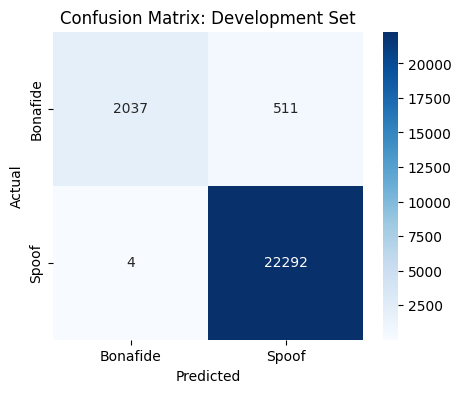

In [ ]:
dev_eer, dev_fig = eval_model(model, dev_dl, device, "Development Set")


========== Evaluation Set Results ==========
EER: 8.3279%
Accuracy:  0.9127
F1 Score:  0.9493
Precision: 0.9903
Recall:    0.9116

Classification Report:
              precision    recall  f1-score   support

    Bonafide       0.55      0.92      0.69      7355
       Spoof       0.99      0.91      0.95     63882

    accuracy                           0.91     71237
   macro avg       0.77      0.92      0.82     71237
weighted avg       0.94      0.91      0.92     71237



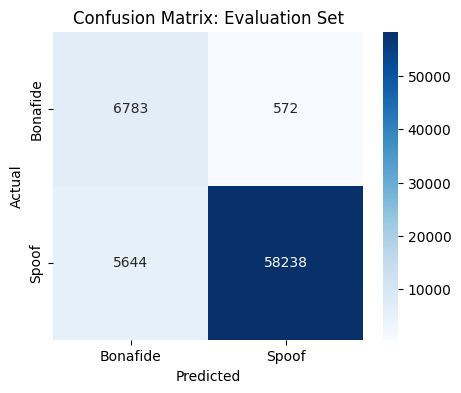

In [ ]:
eval_eer, eval_fig = eval_model(model, eval_dl, device, "Evaluation Set")